# 生产级人脸替换流程

**⚠️ 使用须知**
> 请确保在使用换脸技术前获得相关人员明确授权，并遵守当地法律法规以及平台关于肖像权、隐私和内容真实性的要求。

## 完整流程
```
FFmpeg 抽帧 → InsightFace 检测 → Inswapper 推理 → GFPGAN 修复 → 颜色匹配 → FFmpeg 编码 → 输出 MP4
```

## 0. 安装依赖

> **`basicsr` 兼容性说明**  
> `basicsr` 依赖 `torchvision.transforms.functional_tensor`，该接口在 torchvision ≥ 0.12 中已被移除。
> 下方单元格按正确顺序安装，并在 Cell 1 中自动打补丁，无需手动降级 torchvision。

In [84]:
# 步骤 1：先单独安装 basicsr（固定到兼容版本）
# %pip install "basicsr==1.4.2" --quiet

# 步骤 2：安装其余依赖
# %pip install insightface onnxruntime-gpu opencv-python-headless tqdm facexlib gfpgan --quiet

# ── 没有 NVIDIA GPU 时改用 CPU 版 onnxruntime ──
#%pip install "basicsr==1.4.2" --quiet
#%pip install insightface onnxruntime opencv-python-headless tqdm facexlib gfpgan --quiet

print("安装完成，请【重启内核】后再继续运行后续单元格。")

安装完成，请【重启内核】后再继续运行后续单元格。


## 1. basicsr 兼容性补丁

> **必须在 `import gfpgan` 之前运行此单元格。**  
> 补丁将已移除的 `functional_tensor` 模块注入到 `sys.modules`，让 basicsr 正常 import。

In [85]:
import sys, types
import torchvision.transforms.functional as _F

# torchvision >= 0.12 删除了 functional_tensor 模块，basicsr 仍在引用它
# 此处构造一个最小兼容模块，仅补充 basicsr 实际用到的函数
_ft = types.ModuleType("torchvision.transforms.functional_tensor")
_ft.rgb_to_grayscale = _F.rgb_to_grayscale
sys.modules["torchvision.transforms.functional_tensor"] = _ft

print("✓ basicsr 兼容补丁已应用")

✓ basicsr 兼容补丁已应用


## 2. 环境初始化 & 路径配置

In [86]:
import os
import shutil
import subprocess
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

# ── 用户配置区 ─────────────────────────────────────────
SOURCE_IMAGE       = "IMG_3897.png"          # 源人脸图片
TARGET_VIDEO       = "video.mp4"          # 目标视频
SWAPPER_MODEL      = os.path.expanduser("models/inswapper_128.onnx")
OUTPUT_DIR         = Path("workspace")     # 工作目录
FINAL_OUTPUT       = "final_output_IMG_3897.mp4"  # 最终输出视频文件名
USE_GPU            = False  # Apple M4 无 NVIDIA GPU，使用 CPU/CoreML
ENABLE_GFPGAN      = True   # 开启人脸修复增强
ENABLE_COLOR_MATCH = True   # 开启颜色匹配
GFPGAN_UPSCALE     = 1      # 1=不放大，2=2倍放大
# ──────────────────────────────────────────────────────

FRAMES_DIR = OUTPUT_DIR / "frames"
RESULT_DIR = OUTPUT_DIR / "result_frames"
FRAMES_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

ctx_id = 0 if USE_GPU else -1

print(f"工作目录  : {OUTPUT_DIR.resolve()}")
print(f"GPU 模式  : {USE_GPU}")
print(f"GFPGAN   : {ENABLE_GFPGAN}")
print(f"颜色匹配  : {ENABLE_COLOR_MATCH}")

工作目录  : /Users/winssion/Desktop/faceCopy/workspace
GPU 模式  : False
GFPGAN   : True
颜色匹配  : True


## 3. FFmpeg 抽帧

In [87]:
def extract_frames(video_path: str, output_dir: Path) -> dict:
    """FFmpeg 抽帧为 PNG 无损序列，同时读取视频元数据。"""
    probe_cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-show_entries", "stream=width,height,r_frame_rate",
        "-of", "csv=p=0",
        video_path,
    ]
    out = subprocess.run(probe_cmd, capture_output=True, text=True, check=True)
    parts = out.stdout.strip().split(",")
    width, height = int(parts[0]), int(parts[1])
    fps_num, fps_den = map(int, parts[2].split("/"))
    fps = fps_num / fps_den

    subprocess.run(
        ["ffmpeg", "-y", "-i", video_path, str(output_dir / "%06d.png")],
        check=True, capture_output=True,
    )

    frame_paths = sorted(output_dir.glob("*.png"))
    print(f"视频信息: {width}x{height} @ {fps:.3f} fps，共 {len(frame_paths)} 帧")
    return {"width": width, "height": height, "fps": fps, "frame_paths": frame_paths}


meta = extract_frames(TARGET_VIDEO, FRAMES_DIR)

视频信息: 576x1024 @ 30.000 fps，共 530 帧


## 4. 加载模型

In [88]:
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model

print("加载 InsightFace buffalo_l ...")
face_app = FaceAnalysis(name="buffalo_l",root='./')
face_app.prepare(ctx_id=ctx_id, det_size=(640, 640))

print(f"加载 Inswapper: {SWAPPER_MODEL}")
swapper = get_model(SWAPPER_MODEL, download=False, download_zip=False)

gfpgan_restorer = None
if ENABLE_GFPGAN:
    # 补丁已在 Cell 1 中应用，此处可正常 import
    from gfpgan import GFPGANer
    print("加载 GFPGAN v1.3 ...")
    gfpgan_restorer = GFPGANer(
        model_path="models/GFPGANv1.3.pth",
        upscale=GFPGAN_UPSCALE,
        arch="clean",
        channel_multiplier=2,
        bg_upsampler=None,
    )

print("\n✓ 所有模型加载完毕")

加载 InsightFace buffalo_l ...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


/Users/winssion/miniconda3/envs/faceswap/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


find model: ./models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
加载 Inswapper: models/inswapper_128.onnx
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
inswapper-shape: [1, 3, 128, 128]
加载 GFPGAN v1.3 ...


/Users/winssion/miniconda3/envs/faceswap/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/winssion/miniconda3/envs/faceswap/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



✓ 所有模型加载完毕


## 5. 读取源人脸特征

In [89]:
def get_source_face(image_path: str):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"无法读取: {image_path}")
    faces = face_app.get(img)
    if not faces:
        raise ValueError("源图片中未检测到人脸")
    if len(faces) > 1:
        print(f"⚠ 检测到 {len(faces)} 张人脸，使用面积最大的一张")
        faces.sort(key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]), reverse=True)
    print(f"✓ 源人脸提取成功，置信度: {faces[0].det_score:.3f}")
    return faces[0]


source_face = get_source_face(SOURCE_IMAGE)

✓ 源人脸提取成功，置信度: 0.816


## 6. 颜色匹配工具

In [90]:
def color_match_lab(source: np.ndarray, target: np.ndarray) -> np.ndarray:
    """均值-方差匹配：在 LAB 空间将 source 的颜色分布对齐到 target。"""
    src = cv2.cvtColor(source, cv2.COLOR_BGR2LAB).astype(np.float32)
    tgt = cv2.cvtColor(target, cv2.COLOR_BGR2LAB).astype(np.float32)
    out = src.copy()
    for c in range(3):
        s_mean, s_std = src[:, :, c].mean(), src[:, :, c].std()
        t_mean, t_std = tgt[:, :, c].mean(), tgt[:, :, c].std()
        if s_std < 1e-6:
            continue
        out[:, :, c] = (src[:, :, c] - s_mean) * (t_std / s_std) + t_mean
    return cv2.cvtColor(np.clip(out, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)


def face_bbox_padded(frame: np.ndarray, face, pad: int = 20):
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in face.bbox]
    return max(0, x1-pad), max(0, y1-pad), min(w, x2+pad), min(h, y2+pad)


print("✓ 颜色匹配函数就绪")

✓ 颜色匹配函数就绪


## 7. 逐帧换脸主循环

In [91]:
def process_frame(frame: np.ndarray, src_face) -> np.ndarray:
    target_faces = face_app.get(frame)
    if not target_faces:
        return frame

    result = frame.copy()

    for tgt_face in target_faces:
        # ① 换脸
        result = swapper.get(result, tgt_face, src_face, paste_back=True)

        # ② 颜色匹配
        if ENABLE_COLOR_MATCH:
            x1, y1, x2, y2 = face_bbox_padded(frame, tgt_face)
            ref_roi     = frame[y1:y2, x1:x2]
            swapped_roi = result[y1:y2, x1:x2]
            if ref_roi.size and swapped_roi.size:
                matched = color_match_lab(swapped_roi, ref_roi)
                # alpha 混合，避免矫枉过正
                result[y1:y2, x1:x2] = cv2.addWeighted(matched, 0.6, swapped_roi, 0.4, 0)

    # ③ GFPGAN 修复
    if ENABLE_GFPGAN and gfpgan_restorer is not None:
        _, _, result = gfpgan_restorer.enhance(
            result, has_aligned=False, only_center_face=False, paste_back=True
        )

    return result


frame_paths  = meta["frame_paths"]
failed_names = []

for fp in tqdm(frame_paths, desc="换脸进度", unit="frame"):
    frame = cv2.imread(str(fp))
    if frame is None:
        failed_names.append(fp.name)
        continue
    try:
        processed = process_frame(frame, source_face)
    except Exception as e:
        print(f"\n⚠ {fp.name} 失败: {e}，保留原帧")
        processed = frame
        failed_names.append(fp.name)
    cv2.imwrite(str(RESULT_DIR / fp.name), processed)

print(f"\n✓ 处理完成，共 {len(frame_paths)} 帧")
if failed_names:
    print(f"⚠ 失败帧 ({len(failed_names)} 帧): {failed_names[:5]} ...")

换脸进度: 100%|██████████| 530/530 [48:01<00:00,  5.44s/frame]


✓ 处理完成，共 530 帧


## 8. FFmpeg 编码 + 合并原音频

In [92]:
def encode_video(
    frames_dir: Path,
    audio_source: str,
    output: str,
    fps: float,
    crf: int = 18,
    preset: str = "slow",
):
    tmp = str(OUTPUT_DIR / "_tmp.mp4")

    # 帧序列 → 无音轨视频
    subprocess.run([
        "ffmpeg", "-y",
        "-framerate", str(fps),
        "-i", str(frames_dir / "%06d.png"),
        "-c:v", "libx264",
        "-crf", str(crf),
        "-preset", preset,
        "-pix_fmt", "yuv420p",
        tmp,
    ], check=True, capture_output=True)
    print("视频编码完成")

    # 合并原音轨
    subprocess.run([
        "ffmpeg", "-y",
        "-i", tmp,
        "-i", audio_source,
        "-map", "0:v",
        "-map", "1:a?",   # ? → 原视频无音轨时不报错
        "-c:v", "copy",
        "-c:a", "aac",
        "-shortest",
        output,
    ], check=True, capture_output=True)
    print("音频合并完成")

    os.remove(tmp)
    print(f"✓ 最终视频: {output}")


encode_video(
    frames_dir=RESULT_DIR,
    audio_source=TARGET_VIDEO,
    output=FINAL_OUTPUT,
    fps=meta["fps"],
)

视频编码完成
音频合并完成
✓ 最终视频: final_output_IMG_3897.mp4


## 9. 结果预览

/var/folders/vx/bj__6wtx30b_7h3yvlr6q2m80000gn/T/ipykernel_68060/3490501828.py:11: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vx/bj__6wtx30b_7h3yvlr6q2m80000gn/T/ipykernel_68060/3490501828.py:11: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vx/bj__6wtx30b_7h3yvlr6q2m80000gn/T/ipykernel_68060/3490501828.py:11: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vx/bj__6wtx30b_7h3yvlr6q2m80000gn/T/ipykernel_68060/3490501828.py:11: UserWarning: Glyph 25442 (\N{CJK UNIFIED IDEOGRAPH-6362}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vx/bj__6wtx30b_7h3yvlr6q2m80000gn/T/ipykernel_68060/3490501828.py:11: UserWarning: Glyph 33080 (\N{CJK UNIFIED IDEOGRAPH-8138}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vx/bj__

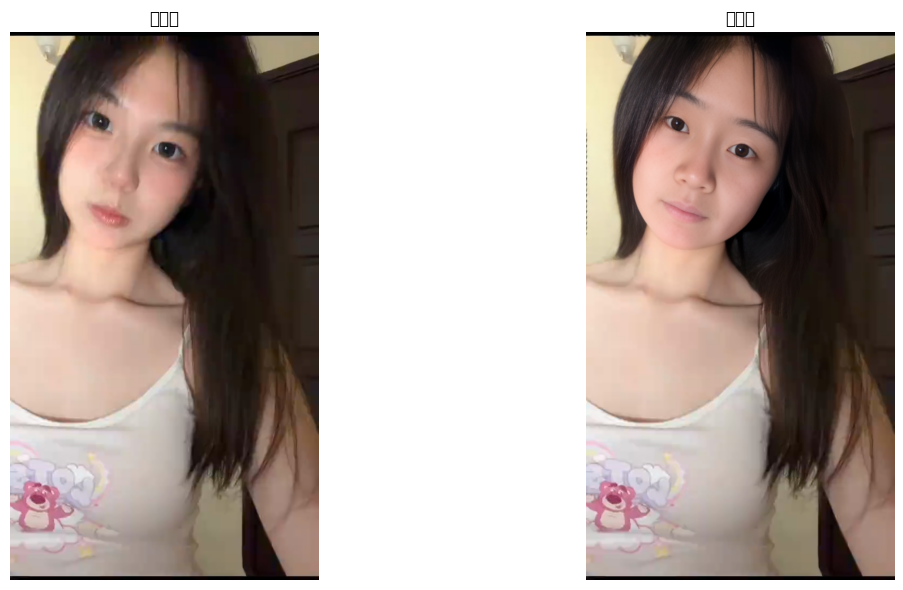

In [93]:
import matplotlib.pyplot as plt
from IPython.display import Video, display

sample = f"{1:06d}.png"
orig   = cv2.cvtColor(cv2.imread(str(FRAMES_DIR / sample)), cv2.COLOR_BGR2RGB)
swapped = cv2.cvtColor(cv2.imread(str(RESULT_DIR / sample)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(orig);    axes[0].set_title("原始帧"); axes[0].axis("off")
axes[1].imshow(swapped); axes[1].set_title("换脸后"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "comparison.png"), dpi=150)
plt.show()

if Path(FINAL_OUTPUT).exists():
    display(Video(FINAL_OUTPUT, embed=True, width=720))

## 10. 清理中间文件（可选）

In [94]:
# 取消注释以节省磁盘空间
# shutil.rmtree(str(FRAMES_DIR))
# shutil.rmtree(str(RESULT_DIR))
# print("✓ 中间文件已清理")

print("=== 流程总结 ===")
print(f"  源人脸    : {SOURCE_IMAGE}")
print(f"  目标视频  : {TARGET_VIDEO}")
print(f"  总帧数    : {len(meta['frame_paths'])}")
print(f"  分辨率    : {meta['width']}x{meta['height']}")
print(f"  帧率      : {meta['fps']:.3f} fps")
print(f"  最终输出  : {FINAL_OUTPUT}")

=== 流程总结 ===
  源人脸    : IMG_3897.png
  目标视频  : video.mp4
  总帧数    : 530
  分辨率    : 576x1024
  帧率      : 30.000 fps
  最终输出  : final_output_IMG_3897.mp4


---

## 附录 A：basicsr 安装失败排查

| 现象 | 原因 | 解决 |
|------|------|------|
| `ImportError: cannot import name 'rgb_to_grayscale' from 'torchvision.transforms.functional_tensor'` | torchvision ≥ 0.12 删除了该模块 | 已由 Cell 1 的补丁自动修复 |
| `pip install basicsr` 编译失败 | 缺少 C++ 构建工具 | `pip install basicsr==1.4.2 --no-build-isolation` |
| basicsr 安装成功但 import 报错 | 多版本冲突 | `pip install basicsr==1.4.2 --force-reinstall` |
| GFPGAN 权重下载超时 | 网络问题 | 手动下载 `GFPGANv1.3.pth` 后改 `model_path` 为本地路径 |

## 附录 B：其他常见问题

| 问题 | 解决方案 |
|------|----------|
| `inswapper_128.onnx` 找不到 | 从 HuggingFace 下载后放到工作目录 |
| onnxruntime-gpu 版本冲突 | 对照 CUDA 版本选择匹配的 onnxruntime-gpu |
| 换脸边缘接缝明显 | 增大颜色匹配 alpha 或启用 GFPGAN |
| 视频无音频输出 | 确认目标视频含音轨，或将 `-map 1:a?` 改为 `-map 1:a` |
| 内存不足 OOM | 降低 `det_size=(320,320)`，或分批处理帧 |